# 9단계 · 부분 매수/매도 전략 (Partial Position Sizing)

## 핵심 질문: "시장 상황에 따라 부분 매수/매도가 더 낫지 않을까?"

08번 Walk-Forward 결과를 보면 두 가지 문제가 명확하다:
- **진입**: 국면별 고정 비중 → 시장 강도와 무관하게 동일한 비율로 베팅
- **청산**: DOWNTREND 전환 시 즉시 전량 매도 → 단기 변동에 과도하게 반응

---

## 08번 vs 09번 전략 비교

| 구분 | 08번 (ma_regime_strategy) | 09번 (partial_auto_strategy) |
|------|--------------------------|------------------------------|
| **사용 지표** | MA 정렬 + ADX | MA 정렬 + ADX + BB |
| **진입 방식** | 골든크로스 100% / BB 50% 고정 | 골든크로스 40% → MA20 지지 확인 70% / BB 30% 단계적 매수 |
| **청산 방식** | DOWNTREND 즉시 전량(0%) | TRANSITION→40% 유지 → 데드크로스→10% 유지 → DOWNTREND→0% 단계적 매도 |
| **WF 파라미터** | `adx_threshold` 1개 | `adx_threshold` 1개 |
| **포지션 종류** | 이산값 (0/0.5/1.0) | 이산값 (0/0.1/0.3/0.4/0.7) |

### 09번 핵심 아이디어

```
[분할 매수]
  1차: UPTREND + 골든크로스          → 40% 진입
  2차: UPTREND + MA20 지지 재확인    → 70% 추가매수 (추세 강화 확인)
  횡보: SIDEWAYS + BB 하단           → 30% 진입

[단계적 매도]
  TRANSITION 전환 첫날               → 40% 유지 (나머지 익절)
  데드크로스 (MA20 < MA60)           → 10% 유지 (추세 전환 시작)
  DOWNTREND 진입                    → 0% 전량 청산 (하락 확정)
  BB 상단 (횡보 청산)                → 0% 전량 청산
```

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import vectorbt as vbt
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from vbt_backtest import optimizer
from vbt_backtest.config import (
    FEES, SLIPPAGE,
    ADX_PARAM_GRID, WF_TRAIN_MONTHS, WF_TEST_MONTHS,
    ADX_THRESHOLD_DEFAULT, ADX_SIDEWAYS_DEFAULT,
)
from vbt_backtest.strategies.combined import ma_regime_strategy, partial_auto_strategy

# ── 데이터 로드 (08번과 동일) ─────────────────────────────────────────────────
TICKER = '005930.KS'
START  = '2019-01-01'
END    = '2024-12-31'

df = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

close  = df['Close'].squeeze()
high   = df['High'].squeeze()
low    = df['Low'].squeeze()
volume = df['Volume'].squeeze()

print(f'종목  : 삼성전자 ({TICKER})')
print(f'기간  : {close.index[0].date()} ~ {close.index[-1].date()}')
print(f'거래일: {len(close)}일')

종목  : 삼성전자 (005930.KS)
기간  : 2019-01-02 ~ 2024-12-30
거래일: 1475일


---
## 1단계 · 08번 Walk-Forward 재실행 (비교 기준)

08번 결과를 기준선으로 사용하기 위해 동일한 조건으로 재실행한다.

In [2]:
# ── 08번 Walk-Forward (adx_threshold 단일 파라미터) ──────────────────────────
def regime_fn_08(close, high, low, volume=None, adx_threshold=25.0, adx_sideways=20.0,
                 fees=FEES, slippage=SLIPPAGE):
    return ma_regime_strategy.run_backtest(
        close, high, low,
        adx_threshold=adx_threshold,
        adx_sideways=adx_sideways,
        fees=fees, slippage=slippage,
    )

print('08번 Walk-Forward 실행 중...')
wf08 = optimizer.walk_forward(
    close,
    regime_fn_08,
    param_grid=ADX_PARAM_GRID,
    train_months=WF_TRAIN_MONTHS,
    test_months=WF_TEST_MONTHS,
    fees=FEES,
    slippage=SLIPPAGE,
    metric='sharpe_ratio',
    warmup_days=150,
    high=high, low=low, volume=volume,
)

wf08_equity = wf08['equity_curve']
wf08_start  = wf08_equity.index[0]
wf08_end    = wf08_equity.index[-1]

n_years_08 = (wf08_end - wf08_start).days / 365.25
wf08_total  = wf08_equity.iloc[-1] / wf08_equity.iloc[0] - 1
wf08_cagr   = (wf08_equity.iloc[-1] / wf08_equity.iloc[0]) ** (1 / n_years_08) - 1
wf08_daily  = wf08_equity.pct_change().dropna()
wf08_sharpe = wf08_daily.mean() / wf08_daily.std() * np.sqrt(252)
wf08_mdd    = (wf08_equity / wf08_equity.cummax() - 1).min()

print(f'완료: {wf08["n_windows"]}개 윈도우')
print(f'08번 WF 총수익률: {wf08_total:.2%}  CAGR: {wf08_cagr:.2%}  Sharpe: {wf08_sharpe:.2f}  MDD: {wf08_mdd:.2%}')

08번 Walk-Forward 실행 중...
완료: 9개 윈도우
08번 WF 총수익률: 52.62%  CAGR: 9.86%  Sharpe: 1.02  MDD: -13.33%


---
## 2단계 · 09번 핵심 아이디어 시각화

### 분할 매수: 3단계 진입 비중

08번은 국면이 결정되면 비중이 고정된다. 09번은 **추세 확인 단계에 따라** 비중을 늘린다.

| 단계 | 조건 | 목표 비중 | 의미 |
|------|------|---------|------|
| 1차 | UPTREND + 골든크로스 | **40%** | 추세 시작 확인, 보수적 진입 |
| 2차 | UPTREND + MA20 지지 재확인 | **70%** | 추세 강화 확인, 비중 확대 |
| 횡보 | SIDEWAYS + BB 하단 | **30%** | 방향 불명, 최소 진입 |

### 분할 매도: 3단계 청산

| 단계 | 조건 | 유지 비중 | 의미 |
|------|------|---------|------|
| 1차 | TRANSITION 전환 첫날 | **40%** | 추세 약화, 일부 익절 |
| 2차 | 데드크로스 (MA20 < MA60) | **10%** | 추세 전환, 대부분 청산 |
| 3차 | DOWNTREND 진입 | **0%** | 하락 확정, 전량 청산 |
| 횡보 청산 | BB 상단 터치 | **0%** | 목표가 달성 |

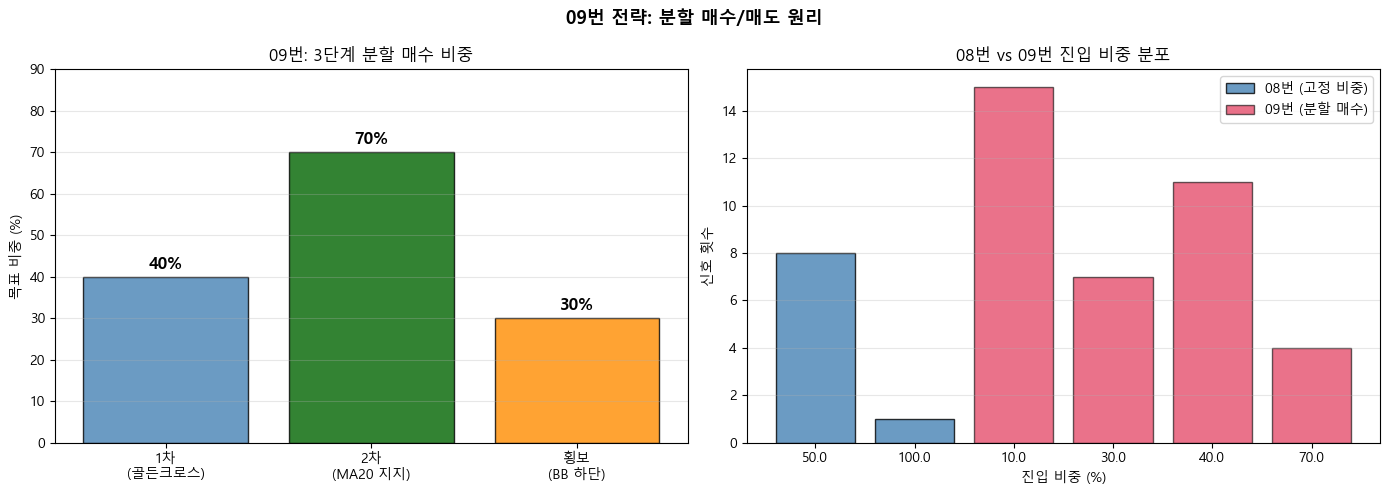

08번 진입 신호 비중값 분포: {50.0: 8, 100.0: 1}
09번 진입 신호 비중값 분포: {10.0: 15, 30.0: 7, 40.0: 11, 70.0: 4}


In [3]:
# ── 08번 vs 09번 신호 생성 (기본 파라미터) ───────────────────────────────────
_, _, size_08, detail_08 = ma_regime_strategy.make_signals(
    close, high, low, adx_threshold=25.0          # volume 불필요 (ma_regime_strategy)
)
_, _, size_09, detail_09 = partial_auto_strategy.make_signals(
    close, high, low, adx_threshold=25.0          # adx_scale 파라미터 없음
)

# 진입 신호만 (0 초과)
s08_pos = size_08.dropna(); s08_pos = s08_pos[s08_pos > 0]
s09_pos = size_09.dropna(); s09_pos = s09_pos[s09_pos > 0]

val_counts_08 = (s08_pos * 100).round(0).value_counts().sort_index()
val_counts_09 = (s09_pos * 100).round(0).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 09번 분할 매수 비중 설명
entry_labels = ['1차\n(골든크로스)', '2차\n(MA20 지지)', '횡보\n(BB 하단)']
entry_values = [40, 70, 30]
entry_colors = ['steelblue', 'darkgreen', 'darkorange']
bars = axes[0].bar(entry_labels, entry_values, color=entry_colors, alpha=0.8, edgecolor='black')
for bar, val in zip(bars, entry_values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 1,
                 f'{val}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylabel('목표 비중 (%)')
axes[0].set_title('09번: 3단계 분할 매수 비중', fontsize=12)
axes[0].set_ylim(0, 90)
axes[0].grid(True, alpha=0.3, axis='y')

# 오른쪽: 08번 vs 09번 진입 비중 분포
axes[1].bar(val_counts_08.index.astype(str), val_counts_08.values,
            color='steelblue', alpha=0.8, edgecolor='black', label='08번 (고정 비중)')
if len(val_counts_09) > 0:
    axes[1].bar(val_counts_09.index.astype(str), val_counts_09.values,
                color='crimson', alpha=0.6, edgecolor='black', label='09번 (분할 매수)')
axes[1].set_xlabel('진입 비중 (%)')
axes[1].set_ylabel('신호 횟수')
axes[1].set_title('08번 vs 09번 진입 비중 분포', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('09번 전략: 분할 매수/매도 원리', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'08번 진입 신호 비중값 분포: {dict(val_counts_08)}')
print(f'09번 진입 신호 비중값 분포: {dict(val_counts_09)}')

---
## 3단계 · 단계적 청산 메커니즘 확인

=== 분할 청산 비교 ===
08번 전량청산 발동 횟수  : 6회  (DOWNTREND 전환 → 0%)
09번 1차 익절 발동 횟수  : 12회  (TRANSITION 전환 → 40% 유지)
09번 2차 청산 발동 횟수  : 15회  (데드크로스 → 10% 유지)
09번 전량청산 발동 횟수  : 6회  (DOWNTREND → 0%)

=== 국면별 일수 분포 ===
  SIDEWAYS    :  679일 (46.0%)
  TRANSITION  :  438일 (29.7%)
  UPTREND     :  257일 (17.4%)
  DOWNTREND   :  101일 (6.8%)


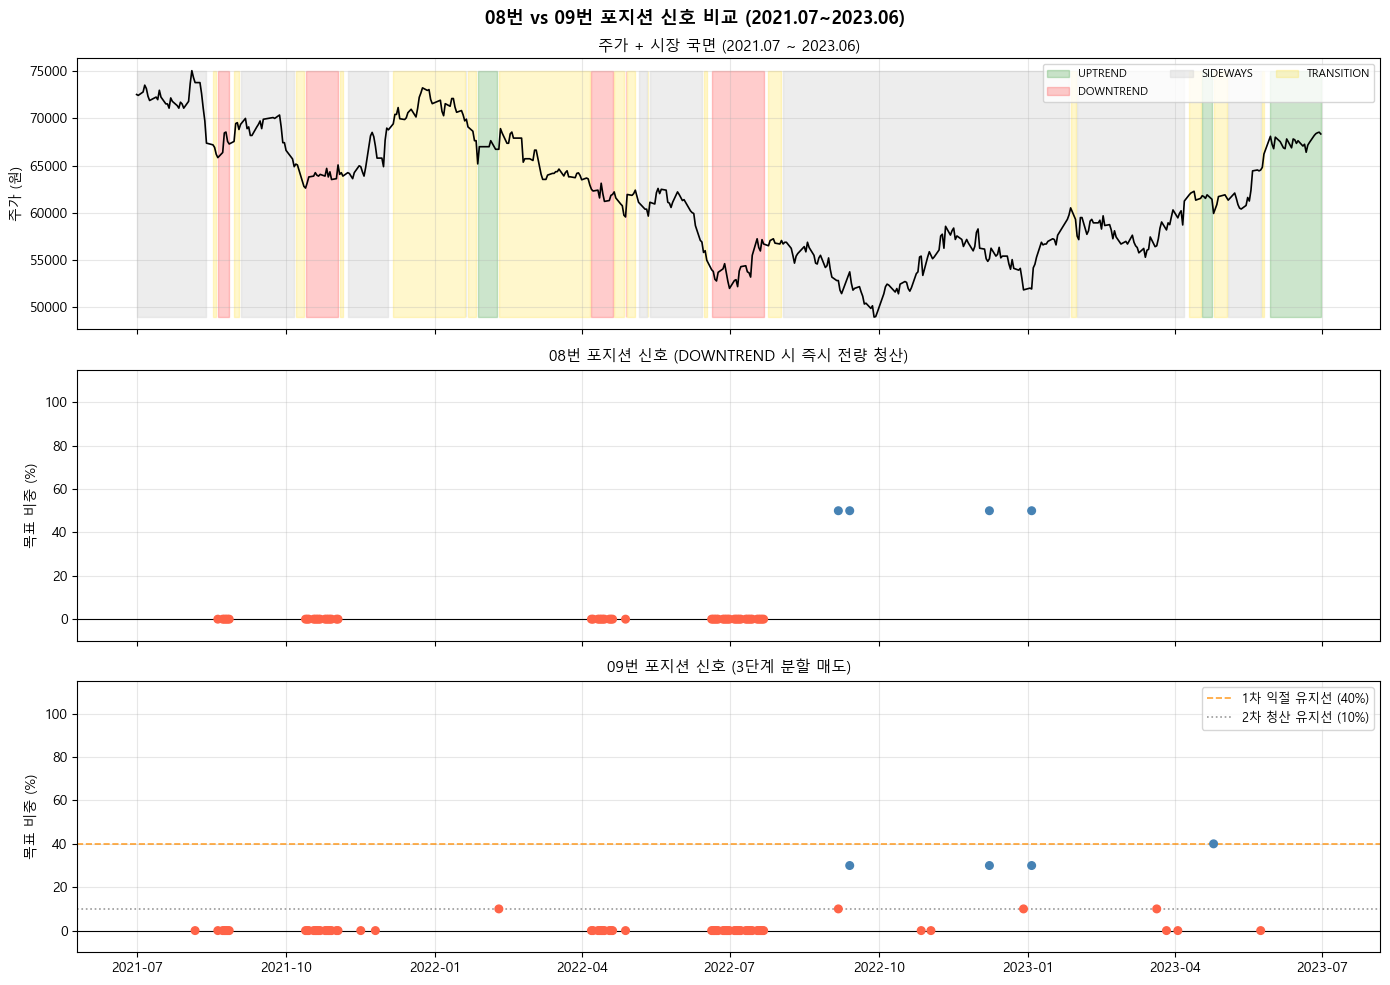

In [4]:
# ── 단계적 청산 신호 추출 ─────────────────────────────────────────────────────
regime_09            = detail_09['regime']
transition_start_09  = detail_09['transition_from_up']   # 1차 익절 → 40% 유지
dead_cross_09        = detail_09['dead_cross']            # 2차 청산 → 10% 유지
downtrend_09         = detail_09['masks']['DOWNTREND']
downtrend_start_09   = downtrend_09 & ~downtrend_09.shift(1).fillna(False)  # 3차 전량 청산

# 08번: DOWNTREND 전환만 전량 청산
downtrend_08       = detail_08['masks']['DOWNTREND']
downtrend_start_08 = downtrend_08 & ~downtrend_08.shift(1).fillna(False)

print('=== 분할 청산 비교 ===')
print(f'08번 전량청산 발동 횟수  : {downtrend_start_08.sum()}회  (DOWNTREND 전환 → 0%)')
print(f'09번 1차 익절 발동 횟수  : {transition_start_09.sum()}회  (TRANSITION 전환 → 40% 유지)')
print(f'09번 2차 청산 발동 횟수  : {dead_cross_09.sum()}회  (데드크로스 → 10% 유지)')
print(f'09번 전량청산 발동 횟수  : {downtrend_start_09.sum()}회  (DOWNTREND → 0%)')
print()

# 국면별 일수 분포
regime_counts = regime_09.value_counts()
total_days = len(regime_09)
print('=== 국면별 일수 분포 ===')
for r, cnt in regime_counts.items():
    print(f'  {r:12s}: {cnt:4d}일 ({cnt/total_days:.1%})')

# ── 단계적 청산 예시 타임라인 (2021~2023 하락장 포함) ─────────────────────────
sample_start = '2021-07-01'
sample_end   = '2023-06-30'

s_close  = close.loc[sample_start:sample_end]
s_reg    = regime_09.loc[sample_start:sample_end]
s_size08 = size_08.loc[sample_start:sample_end]
s_size09 = size_09.loc[sample_start:sample_end]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 상단: 주가 + 국면
from vbt_backtest.strategies.combined.ma_regime_strategy import REGIME_COLORS
for regime_name, (color, alpha) in REGIME_COLORS.items():
    mask = (s_reg == regime_name)
    if mask.any():
        axes[0].fill_between(s_close.index, s_close.min(), s_close.max(),
                             where=mask, alpha=alpha, color=color, label=regime_name)
axes[0].plot(s_close, color='black', linewidth=1.2)
axes[0].set_title('주가 + 시장 국면 (2021.07 ~ 2023.06)', fontsize=11)
axes[0].set_ylabel('주가 (원)')
axes[0].legend(loc='upper right', fontsize=8, ncol=3)
axes[0].grid(True, alpha=0.3)

# 중단: 08번 포지션 신호
axes[1].scatter(s_size08.dropna().index, s_size08.dropna() * 100,
                c=['steelblue' if v > 0 else 'tomato' for v in s_size08.dropna()],
                s=30, zorder=5)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('08번 포지션 신호 (DOWNTREND 시 즉시 전량 청산)', fontsize=11)
axes[1].set_ylabel('목표 비중 (%)')
axes[1].set_ylim(-10, 115)
axes[1].grid(True, alpha=0.3)

# 하단: 09번 포지션 신호
colors_09 = []
for v in s_size09.dropna():
    if v >= 0.6:   colors_09.append('darkgreen')
    elif v >= 0.3: colors_09.append('steelblue')
    else:          colors_09.append('tomato')

axes[2].scatter(s_size09.dropna().index, s_size09.dropna() * 100,
                c=colors_09, s=30, zorder=5)
axes[2].axhline(40, color='darkorange', linestyle='--', linewidth=1.2, alpha=0.8, label='1차 익절 유지선 (40%)')
axes[2].axhline(10, color='gray',       linestyle=':',  linewidth=1.2, alpha=0.8, label='2차 청산 유지선 (10%)')
axes[2].axhline(0,  color='black',      linewidth=0.8)
axes[2].set_title('09번 포지션 신호 (3단계 분할 매도)', fontsize=11)
axes[2].set_ylabel('목표 비중 (%)')
axes[2].set_ylim(-10, 115)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('08번 vs 09번 포지션 신호 비교 (2021.07~2023.06)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4단계 · 09번 Walk-Forward 실행

- **최적화 파라미터**: `adx_threshold` (ADX 임계값)
- **탐색 범위**: [15, 18, 20, 22, 25, 28, 30, 35]
- **최적화 기준**: 샤프비율
- **학습/검증**: 12개월 / 6개월 (08번과 동일)

In [5]:
def regime_fn_09(close, high, low, volume=None,
                 adx_threshold=25.0, adx_sideways=20.0,
                 fees=FEES, slippage=SLIPPAGE):
    return partial_auto_strategy.run_backtest(
        close, high, low,
        adx_threshold=adx_threshold,
        adx_sideways=adx_sideways,
        fees=fees, slippage=slippage,
    )

print('09번 Walk-Forward 실행 중... (adx_threshold 단일 파라미터)')
wf09 = optimizer.walk_forward(
    close,
    regime_fn_09,
    param_grid=ADX_PARAM_GRID,
    train_months=12,
    test_months=6,
    fees=FEES,
    slippage=SLIPPAGE,
    metric='sharpe_ratio',
    warmup_days=150,
    high=high, low=low, volume=volume,
)

wf09_equity = wf09['equity_curve']
wf09_start  = wf09_equity.index[0]
wf09_end    = wf09_equity.index[-1]

n_years_09 = (wf09_end - wf09_start).days / 365.25
wf09_total  = wf09_equity.iloc[-1] / wf09_equity.iloc[0] - 1
wf09_cagr   = (wf09_equity.iloc[-1] / wf09_equity.iloc[0]) ** (1 / n_years_09) - 1
wf09_daily  = wf09_equity.pct_change().dropna()
wf09_sharpe = wf09_daily.mean() / wf09_daily.std() * np.sqrt(252)
wf09_mdd    = (wf09_equity / wf09_equity.cummax() - 1).min()

print(f'완료: {wf09["n_windows"]}개 윈도우')
print(f'09번 WF 총수익률: {wf09_total:.2%}  CAGR: {wf09_cagr:.2%}  Sharpe: {wf09_sharpe:.2f}  MDD: {wf09_mdd:.2%}')

09번 Walk-Forward 실행 중... (adx_threshold 단일 파라미터)
완료: 9개 윈도우
09번 WF 총수익률: 15.66%  CAGR: 3.29%  Sharpe: 0.64  MDD: -8.57%


---
## 5단계 · 구간별 최적 파라미터 비교

In [6]:
rows_08, rows_09 = [], []

for i, (w08, w09) in enumerate(zip(wf08['windows'], wf09['windows'])):
    ret08 = (
        (w08['test_value'].iloc[-1] / w08['test_value'].iloc[0] - 1)
        if w08['test_value'] is not None and len(w08['test_value']) > 0 else float('nan')
    )
    ret09 = (
        (w09['test_value'].iloc[-1] / w09['test_value'].iloc[0] - 1)
        if w09['test_value'] is not None and len(w09['test_value']) > 0 else float('nan')
    )
    rows_08.append({
        '윈도우':     f'W{i+1:02d}',
        '검증 기간':  f"{w08['test_start'].strftime('%y.%m')}~{w08['test_end'].strftime('%y.%m')}",
        '최적 ADX':   w08['best_params']['adx_threshold'],
        '학습 Sharpe': round(w08['best_score'], 3),
        '검증 수익률': f'{ret08:.2%}' if not np.isnan(ret08) else 'N/A',
    })
    rows_09.append({
        '윈도우':     f'W{i+1:02d}',
        '검증 기간':  f"{w09['test_start'].strftime('%y.%m')}~{w09['test_end'].strftime('%y.%m')}",
        '최적 ADX':   w09['best_params']['adx_threshold'],
        '학습 Sharpe': round(w09['best_score'], 3),
        '검증 수익률': f'{ret09:.2%}' if not np.isnan(ret09) else 'N/A',
    })

df08 = pd.DataFrame(rows_08).set_index('윈도우')
df09 = pd.DataFrame(rows_09).set_index('윈도우')

print('=== 08번 구간별 결과 (ma_regime_strategy) ===')
print(df08.to_string())
print()
print('=== 09번 구간별 결과 (partial_auto_strategy) ===')
print(df09.to_string())

=== 08번 구간별 결과 (ma_regime_strategy) ===
           검증 기간  최적 ADX  학습 Sharpe  검증 수익률
윈도우                                        
W01  20.01~20.07      15      2.089   0.00%
W02  20.07~20.12      15       -inf  22.21%
W03  21.01~21.07      15      1.950  -1.64%
W04  21.07~21.12      15      2.098  -0.61%
W05  22.01~22.07      15     -0.052   0.00%
W06  22.07~22.12      15       -inf  -1.01%
W07  23.01~23.06      15     -0.121  15.76%
W08  23.07~23.12      15      1.583   9.27%
W09  24.01~24.07      15      2.382   2.02%

=== 09번 구간별 결과 (partial_auto_strategy) ===
           검증 기간  최적 ADX  학습 Sharpe  검증 수익률
윈도우                                        
W01  20.01~20.07      28      2.685  -1.79%
W02  20.07~20.12      15     -0.250  13.32%
W03  21.01~21.07      22      1.859  -0.54%
W04  21.07~21.12      15      2.227   0.49%
W05  22.01~22.07      15      0.448  -0.52%
W06  22.07~22.12      15     -0.854  -0.98%
W07  23.01~23.06      15     -0.392   2.42%
W08  23.07~23.12      25      1.186 

---
## 6단계 · 비교 분석: 4개 전략 자산 곡선

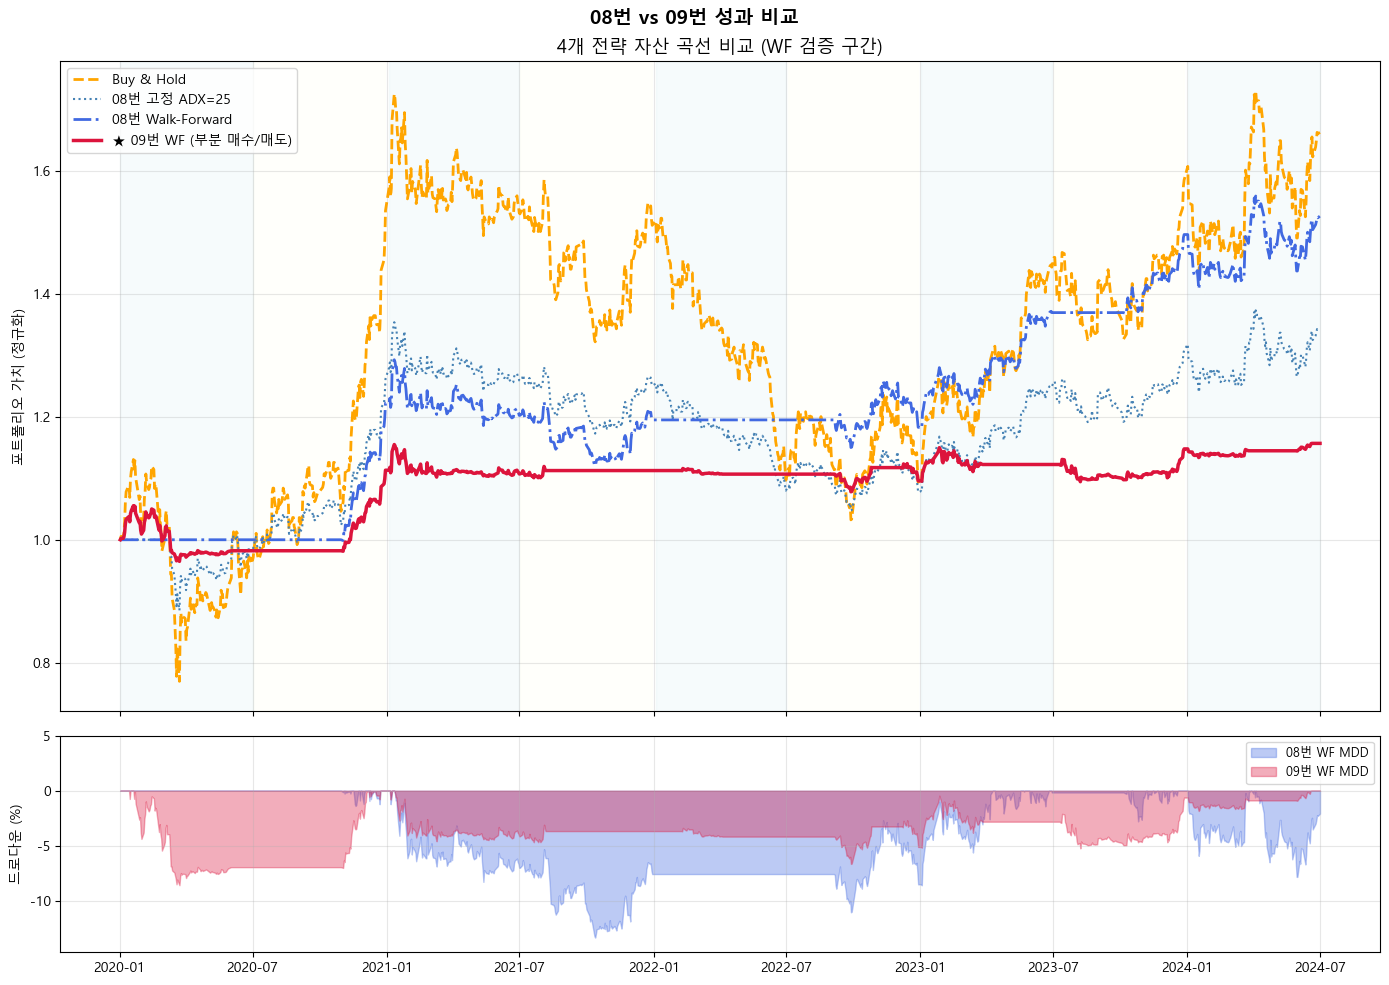

In [7]:
# 공통 기준 기간 (WF 검증 시작 ~ 종료)
common_start = wf08_equity.index[0]
common_end   = min(wf08_equity.index[-1], wf09_equity.index[-1])
close_period = close.loc[common_start:common_end]

# Buy & Hold
bh_e = pd.Series(False, index=close_period.index); bh_e.iloc[0] = True
bh_x = pd.Series(False, index=close_period.index); bh_x.iloc[-1] = True
pf_bh = vbt.Portfolio.from_signals(
    close_period, bh_e, bh_x, fees=FEES, slippage=SLIPPAGE, freq='D'
)
bh_val = pf_bh.value()

# 08번 고정 ADX=25
pf_fixed08 = ma_regime_strategy.run_backtest(
    close_period,
    high.loc[common_start:common_end],
    low.loc[common_start:common_end],
    volume.loc[common_start:common_end],
    adx_threshold=25.0, fees=FEES, slippage=SLIPPAGE,
)
fixed08_val = pf_fixed08.value()

# 정규화 (동일 시작점)
init_val = wf08_equity.iloc[0]

bh_norm      = bh_val / bh_val.iloc[0] * init_val
fixed08_norm = fixed08_val / fixed08_val.iloc[0] * init_val
wf08_plot    = wf08_equity.loc[:common_end]
wf09_plot    = wf09_equity.loc[:common_end]

# ── 시각화 ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                                gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax1.plot(bh_norm,      color='orange',    linewidth=2.0, linestyle='--',  label='Buy & Hold')
ax1.plot(fixed08_norm, color='steelblue', linewidth=1.5, linestyle=':',   label='08번 고정 ADX=25')
ax1.plot(wf08_plot,    color='royalblue', linewidth=2.0, linestyle='-.',  label='08번 Walk-Forward')
ax1.plot(wf09_plot,    color='crimson',   linewidth=2.5, linestyle='-',   label='★ 09번 WF (부분 매수/매도)')

# 검증 구간 배경
for i, w in enumerate(wf09['windows']):
    color = 'lightblue' if i % 2 == 0 else 'lightyellow'
    ax1.axvspan(w['test_start'], min(w['test_end'], common_end), alpha=0.10, color=color)

ax1.set_title('4개 전략 자산 곡선 비교 (WF 검증 구간)', fontsize=13)
ax1.set_ylabel('포트폴리오 가치 (정규화)')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# 드로다운 비교 (08 WF vs 09 WF)
dd08 = (wf08_plot / wf08_plot.cummax() - 1) * 100
dd09 = (wf09_plot / wf09_plot.cummax() - 1) * 100

ax2.fill_between(dd08.index, 0, dd08, color='royalblue', alpha=0.35, label='08번 WF MDD')
ax2.fill_between(dd09.index, 0, dd09, color='crimson',   alpha=0.35, label='09번 WF MDD')
ax2.set_ylabel('드로다운 (%)')
ax2.set_ylim(min(dd08.min(), dd09.min()) * 1.1, 5)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('08번 vs 09번 성과 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7단계 · 성과 비교 테이블

In [8]:
n_years_common = (common_end - common_start).days / 365.25

def calc_metrics(equity: pd.Series, n_years: float, label: str) -> dict:
    total  = equity.iloc[-1] / equity.iloc[0] - 1
    cagr   = (equity.iloc[-1] / equity.iloc[0]) ** (1 / n_years) - 1
    dr     = equity.pct_change().dropna()
    sharpe = dr.mean() / dr.std() * np.sqrt(252) if dr.std() > 0 else float('nan')
    mdd    = (equity / equity.cummax() - 1).min()
    calmar = cagr / abs(mdd) if mdd < 0 else float('nan')
    return {
        '전략':          label,
        '총 수익률':     f'{total:.2%}',
        '연평균(CAGR)':  f'{cagr:.2%}',
        '샤프비율':      f'{sharpe:.2f}',
        '최대낙폭(MDD)': f'{mdd:.2%}',
        'Calmar비율':    f'{calmar:.2f}' if not np.isnan(calmar) else 'N/A',
    }

rows_perf = [
    calc_metrics(bh_norm,      n_years_common, 'Buy & Hold'),
    calc_metrics(fixed08_norm, n_years_common, '08번 고정 ADX=25'),
    calc_metrics(wf08_plot,    n_years_common, '08번 Walk-Forward'),
    calc_metrics(wf09_plot,    n_years_common, '★ 09번 WF (부분 매수/매도)'),
]

df_perf = pd.DataFrame(rows_perf).set_index('전략')
print(f'=== 성과 비교 ({common_start.date()} ~ {common_end.date()}) ===')
print(df_perf.to_string())

# 개선 여부 요약
wf08_total_num = wf08_equity.iloc[-1] / wf08_equity.iloc[0] - 1
wf09_total_num = wf09_plot.iloc[-1] / wf09_plot.iloc[0] - 1

print()
print(f'▶ 08번 대비 09번 총수익률 변화: {wf08_total_num:.2%} → {wf09_total_num:.2%}  '
      f'({"↑ 개선" if wf09_total_num > wf08_total_num else "↓ 악화"})')

dd08_min = (wf08_plot / wf08_plot.cummax() - 1).min()
dd09_min = (wf09_plot / wf09_plot.cummax() - 1).min()
print(f'▶ 08번 대비 09번 MDD 변화: {dd08_min:.2%} → {dd09_min:.2%}  '
      f'({"↑ 방어력 개선" if dd09_min > dd08_min else "↓ 방어력 악화"})')

=== 성과 비교 (2020-01-02 ~ 2024-07-01) ===
                      총 수익률 연평균(CAGR)  샤프비율 최대낙폭(MDD) Calmar비율
전략                                                            
Buy & Hold           66.18%    11.96%  0.58   -40.14%     0.30
08번 고정 ADX=25        34.42%     6.80%  0.59   -22.62%     0.30
08번 Walk-Forward     52.62%     9.86%  1.02   -13.33%     0.74
★ 09번 WF (부분 매수/매도)  15.66%     3.29%  0.64    -8.57%     0.38

▶ 08번 대비 09번 총수익률 변화: 52.62% → 15.66%  (↓ 악화)
▶ 08번 대비 09번 MDD 변화: -13.33% → -8.57%  (↑ 방어력 개선)


---
## 8단계 · 구간별 비교: 하락장에서 부분 청산의 효과

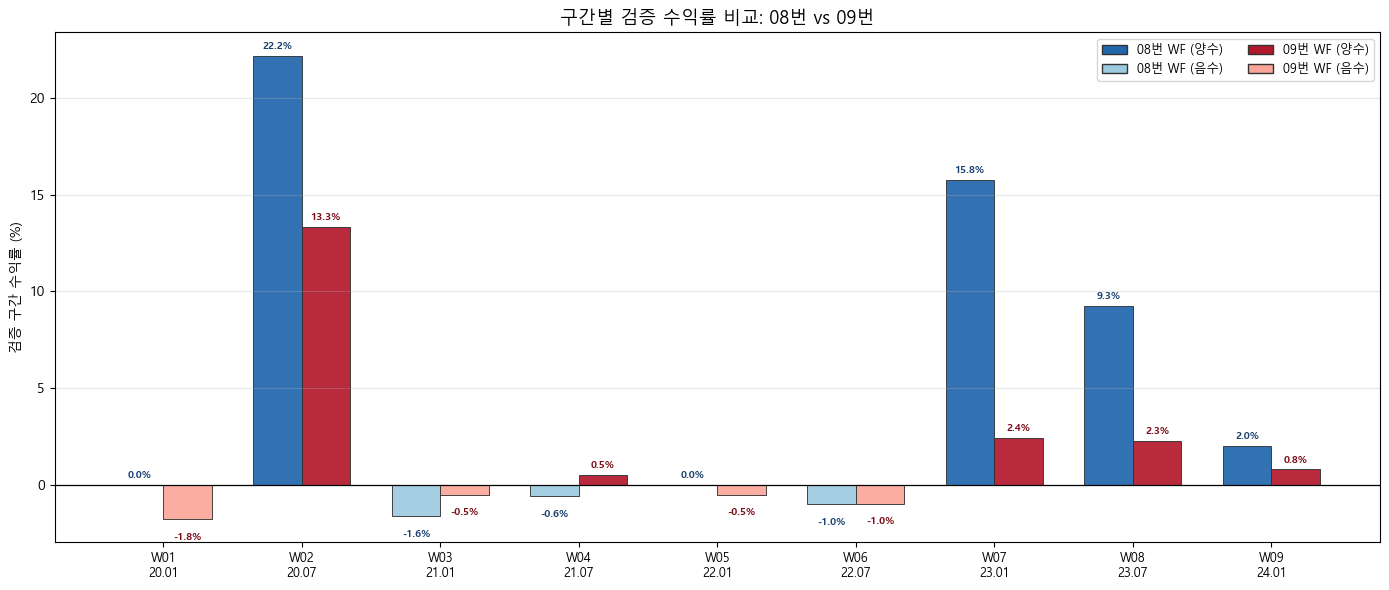


구간별 09번 우위: 3/9개 윈도우
  구간	08번	09번	결과
  W01	0.0%	-1.8%	08 ↑
  W02	22.2%	13.3%	08 ↑
  W03	-1.6%	-0.5%	09 ↑
  W04	-0.6%	0.5%	09 ↑
  W05	0.0%	-0.5%	08 ↑
  W06	-1.0%	-1.0%	09 ↑
  W07	15.8%	2.4%	08 ↑
  W08	9.3%	2.3%	08 ↑
  W09	2.0%	0.8%	08 ↑


In [9]:
n_windows = min(len(wf08['windows']), len(wf09['windows']))
labels    = [f"W{i+1:02d}\n{w['test_start'].strftime('%y.%m')}" for i, w in enumerate(wf09['windows'][:n_windows])]

rets_08 = []
rets_09 = []
for w08, w09 in zip(wf08['windows'][:n_windows], wf09['windows'][:n_windows]):
    r08 = (w08['test_value'].iloc[-1] / w08['test_value'].iloc[0] - 1) * 100 \
          if w08['test_value'] is not None and len(w08['test_value']) > 0 else 0
    r09 = (w09['test_value'].iloc[-1] / w09['test_value'].iloc[0] - 1) * 100 \
          if w09['test_value'] is not None and len(w09['test_value']) > 0 else 0
    rets_08.append(r08)
    rets_09.append(r09)

x = np.arange(n_windows)
w_bar = 0.35

# 전략별 색상 계열 고정
# 08번: 파란 계열 (양수=진파랑 / 음수=연파랑)
# 09번: 빨간 계열 (양수=진빨강 / 음수=연분홍)
C08_POS, C08_NEG = '#2166ac', '#9ecae1'
C09_POS, C09_NEG = '#b2182b', '#fca69a'

fig, ax = plt.subplots(figsize=(14, 6))

bars08 = ax.bar(x - w_bar/2, rets_08, w_bar,
                color=[C08_POS if r >= 0 else C08_NEG for r in rets_08],
                alpha=0.92, edgecolor='#333333', linewidth=0.7,
                label='08번 WF')
bars09 = ax.bar(x + w_bar/2, rets_09, w_bar,
                color=[C09_POS if r >= 0 else C09_NEG for r in rets_09],
                alpha=0.92, edgecolor='#333333', linewidth=0.7,
                label='09번 WF (부분 매수/매도)')

ax.axhline(0, color='black', linewidth=0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('검증 구간 수익률 (%)')
ax.set_title('구간별 검증 수익률 비교: 08번 vs 09번', fontsize=13)

# 범례: 색상 의미 설명 포함
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=C08_POS, edgecolor='#333333', label='08번 WF (양수)'),
    Patch(facecolor=C08_NEG, edgecolor='#333333', label='08번 WF (음수)'),
    Patch(facecolor=C09_POS, edgecolor='#333333', label='09번 WF (양수)'),
    Patch(facecolor=C09_NEG, edgecolor='#333333', label='09번 WF (음수)'),
]
ax.legend(handles=legend_handles, fontsize=9, ncol=2, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# 수치 레이블
for bar, val in zip(bars08, rets_08):
    ypos = val + 0.25 if val >= 0 else val - 0.7
    va   = 'bottom' if val >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:.1f}%', ha='center', va=va, fontsize=7.5,
            color='#1a4070', fontweight='bold')
for bar, val in zip(bars09, rets_09):
    ypos = val + 0.25 if val >= 0 else val - 0.7
    va   = 'bottom' if val >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:.1f}%', ha='center', va=va, fontsize=7.5,
            color='#7a0c15', fontweight='bold')

plt.tight_layout()
plt.show()

# 08 vs 09 구간별 승패
wins = sum(1 for r8, r9 in zip(rets_08, rets_09) if r9 > r8)
print(f'\n구간별 09번 우위: {wins}/{n_windows}개 윈도우')
print('  구간\t08번\t09번\t결과')
for i, (r8, r9) in enumerate(zip(rets_08, rets_09)):
    result = '09 ↑' if r9 > r8 else '08 ↑'
    print(f'  W{i+1:02d}\t{r8:.1f}%\t{r9:.1f}%\t{result}')

---
## 정리

### 08번 vs 09번 핵심 차이 요약

| 관찰 | 08번 | 09번 | 해석 |
|------|------|------|------|
| 진입 비중 | 고정 (100%/50%) | 단계적 (40%→70%/30%) | 추세 확인 후 비중 확대 |
| 청산 방식 | DOWNTREND 즉시 전량 | TRANSITION→데드크로스→DOWNTREND 단계적 | 단기 변동에 덜 반응 |
| 사용 지표 | MA 정렬 + ADX | MA 정렬 + ADX + BB | BB로 횡보장 진입/청산 |
| WF 파라미터 | adx_threshold 1개 | adx_threshold 1개 | 동일 |

### 어떤 시장에서 유리한가?

| 시장 상황 | 09번이 유리 | 이유 |
|-----------|------------|------|
| 추세 전환 구간 (TRANSITION) | ✅ | 즉시 청산 대신 40% 유지로 반등 포착 가능 |
| 완만한 하락 (데드크로스 → DOWNTREND) | ✅ | 단계적 축소로 손실 분산 |
| 강한 단방향 상승 (UPTREND 지속) | ✅ | MA20 지지 확인 후 70%까지 비중 확대 |
| 급격한 하락 (바로 DOWNTREND) | ❌ | TRANSITION 단계 없이 급락 시 40% 유지가 오히려 손실 |

### 다음 개선 방향

```
1. exit1_size / exit2_size 최적화: Walk-Forward에 포함 (현재 고정값 0.4/0.1)
2. recent_window 최적화: 2차 매수 유효기간 파라미터화 (현재 고정 60일)
3. 다중 종목: 삼성전자 외 종목에 적용 → 전략 범용성 검증
4. 변동성 기반 사이징: ATR로 포지션 크기 동적 조절
```